In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")
print(df.head())
print(df.shape)
print(df.columns)

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156  11-08-2016  11-11-2016    Second Class    CG-12520   
1       2  CA-2016-152156  11-08-2016  11-11-2016    Second Class    CG-12520   
2       3  CA-2016-138688  06-12-2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10-11-2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10-11-2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

important_cols = ["Sales", "Profit", "Quantity", "Discount", "Category", "Sub-Category", "Region"]
df = df.dropna(subset=["Order Date"] + important_cols).reset_index(drop=True)

print(df.info())
print(df.isnull().sum())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4042 entries, 0 to 4041
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         4042 non-null   int64         
 1   Order ID       4042 non-null   object        
 2   Order Date     4042 non-null   datetime64[ns]
 3   Ship Date      2739 non-null   datetime64[ns]
 4   Ship Mode      4042 non-null   object        
 5   Customer ID    4042 non-null   object        
 6   Customer Name  4042 non-null   object        
 7   Segment        4042 non-null   object        
 8   Country        4042 non-null   object        
 9   City           4042 non-null   object        
 10  State          4042 non-null   object        
 11  Postal Code    4042 non-null   int64         
 12  Region         4042 non-null   object        
 13  Product ID     4042 non-null   object        
 14  Category       4042 non-null   object        
 15  Sub-Category   4042 n

In [ ]:
df["year"] = df["Order Date"].dt.year
df["month"] = df["Order Date"].dt.month
df["day"] = df["Order Date"].dt.day
df["day_of_week"] = df["Order Date"].dt.dayofweek
df["quarter"] = df["Order Date"].dt.quarter

df["is_profitable"] = (df["Profit"] > 0).astype(int)

print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12        NaT    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11        NaT  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11        NaT  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...     Sales  \
0      Claire Gute   Consumer  United States        Henderson  ...  261.9600   
1      Claire Gute   Consumer  United States        Henderson  ...  731.9400   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   14.6200   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...  957.5775   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   22.3680   

   Quantity Discount    Profit  year month d

1

/tmp/ipykernel_10849/1416906349.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()


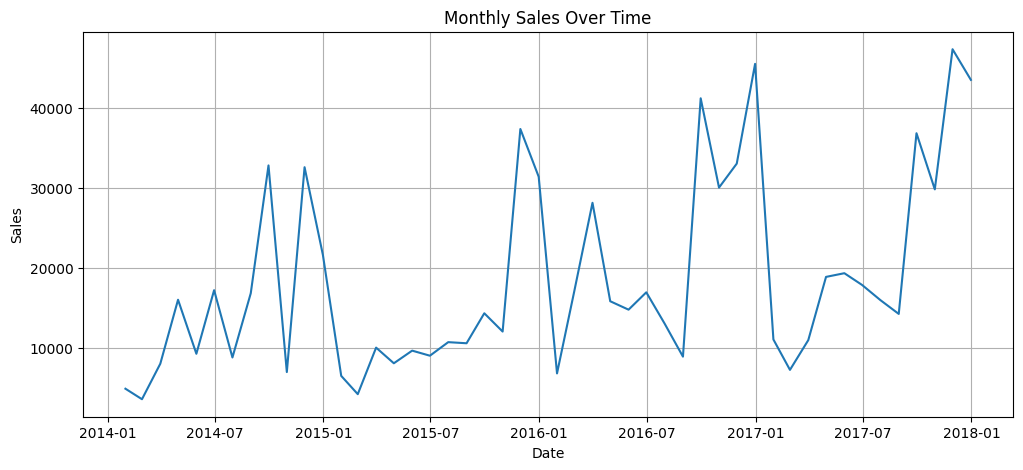

In [ ]:
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

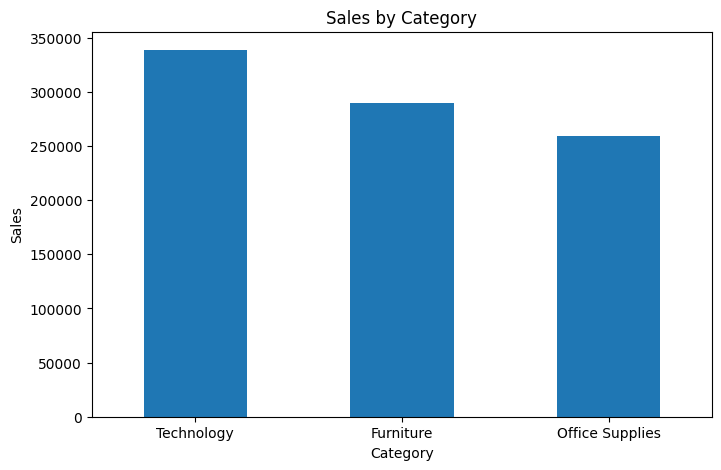

In [ ]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

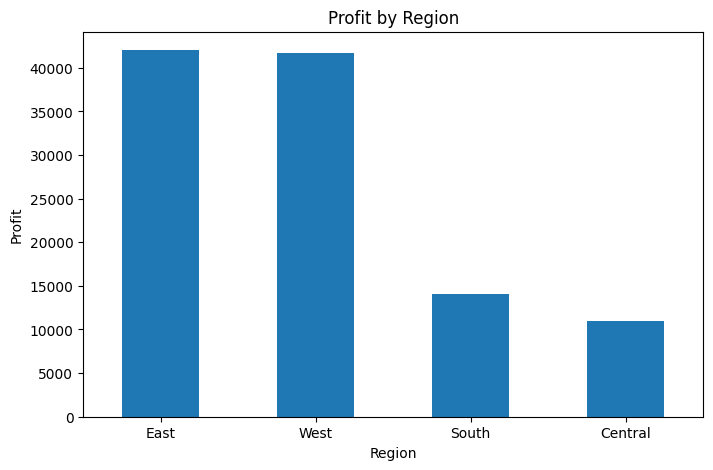

In [ ]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_profit.plot(kind="bar")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.show()

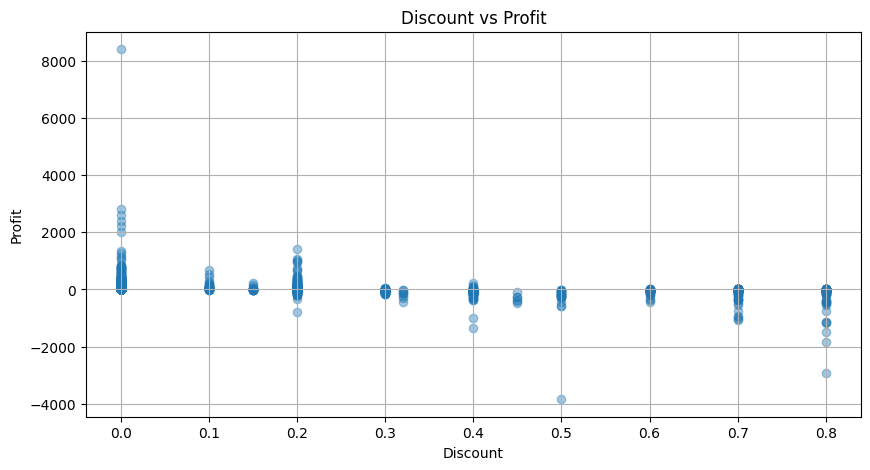

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(df["Discount"], df["Profit"], alpha=0.4)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(True)
plt.show()

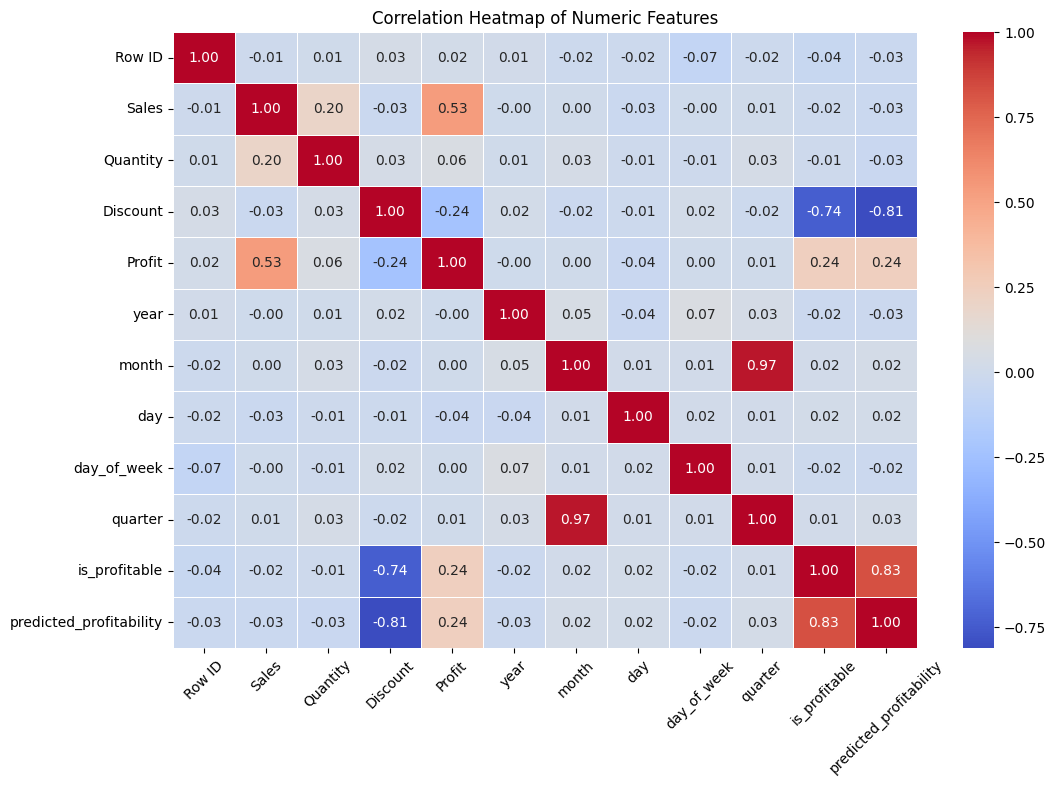

In [ ]:

# اختيار الأعمدة الرقمية بدون Postal Code
numeric_df = df.select_dtypes(include=["number"]).drop(columns=["Postal Code"], errors="ignore")

# حساب الارتباط
corr_matrix = numeric_df.corr()

# الرسم
plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Features")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

2

In [ ]:
monthly_df = df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum().reset_index()

monthly_df["year"] = monthly_df["Order Date"].dt.year
monthly_df["month"] = monthly_df["Order Date"].dt.month
monthly_df["quarter"] = monthly_df["Order Date"].dt.quarter
monthly_df["time_index"] = np.arange(len(monthly_df))

print(monthly_df.head())

  Order Date      Sales  year  month  quarter  time_index
0 2014-01-31   4923.616  2014      1        1           0
1 2014-02-28   3610.402  2014      2        1           1
2 2014-03-31   8048.773  2014      3        1           2
3 2014-04-30  16040.811  2014      4        2           3
4 2014-05-31   9288.864  2014      5        2           4


/tmp/ipykernel_10849/4155941466.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_df = df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum().reset_index()


In [ ]:
X_forecast = monthly_df[["year", "month", "quarter", "time_index"]]
y_forecast = monthly_df["Sales"]

print(X_forecast.shape)
print(y_forecast.shape)

(48, 4)
(48,)


In [ ]:
split_index = int(len(monthly_df) * 0.8)

X_train_f = X_forecast.iloc[:split_index]
X_test_f = X_forecast.iloc[split_index:]

y_train_f = y_forecast.iloc[:split_index]
y_test_f = y_forecast.iloc[split_index:]

test_dates = monthly_df["Order Date"].iloc[split_index:]

In [ ]:
forecast_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

forecast_model.fit(X_train_f, y_train_f)
print("Forecast model trained successfully.")

Forecast model trained successfully.


In [ ]:
y_pred_f = forecast_model.predict(X_test_f)

forecast_results = pd.DataFrame({
    "Order Date": test_dates.values,
    "Actual Sales": y_test_f.values,
    "Predicted Sales": y_pred_f
})

print(forecast_results.head())

  Order Date  Actual Sales  Predicted Sales
0 2017-03-31    10997.7420     14558.976970
1 2017-04-30    18896.3015     13874.122401
2 2017-05-31    19357.8208     13473.630394
3 2017-06-30    17888.3560     13980.315092
4 2017-07-31    15992.8080     13973.068561


In [ ]:
mae = mean_absolute_error(y_test_f, y_pred_f)
mse = mean_squared_error(y_test_f, y_pred_f)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_f, y_pred_f)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 3885.837516050018
MSE: 19227659.2857498
RMSE: 4384.935493909779
R2 Score: 0.8731411541327201


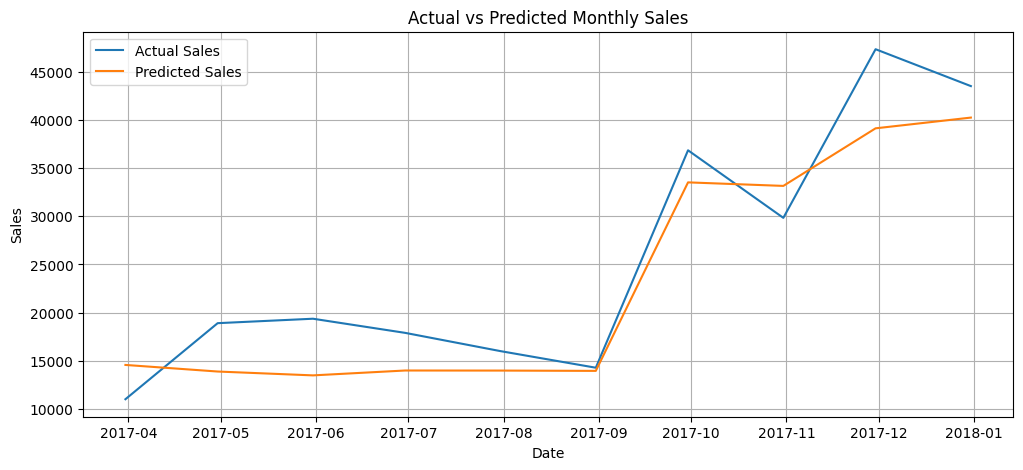

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(test_dates, y_test_f.values, label="Actual Sales")
plt.plot(test_dates, y_pred_f, label="Predicted Sales")
plt.title("Actual vs Predicted Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
last_date = monthly_df["Order Date"].max()
future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1), periods=24, freq="M")

future_df = pd.DataFrame({"Order Date": future_dates})
future_df["year"] = future_df["Order Date"].dt.year
future_df["month"] = future_df["Order Date"].dt.month
future_df["quarter"] = future_df["Order Date"].dt.quarter
future_df["time_index"] = np.arange(len(monthly_df), len(monthly_df) + len(future_df))

future_predictions = forecast_model.predict(future_df[["year", "month", "quarter", "time_index"]])
future_df["Predicted Sales"] = future_predictions

print(future_df)

  Order Date  year  month  quarter  time_index  Predicted Sales
0 2018-01-31  2018      1        1          48     11160.142082
1 2018-02-28  2018      2        1          49     10198.139057
2 2018-03-31  2018      3        1          50     14558.976970
3 2018-04-30  2018      4        2          51     13874.122401
4 2018-05-31  2018      5        2          52     13473.630394
5 2018-06-30  2018      6        2          53     13980.315092


/tmp/ipykernel_10849/4041043211.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1), periods=6, freq="M")


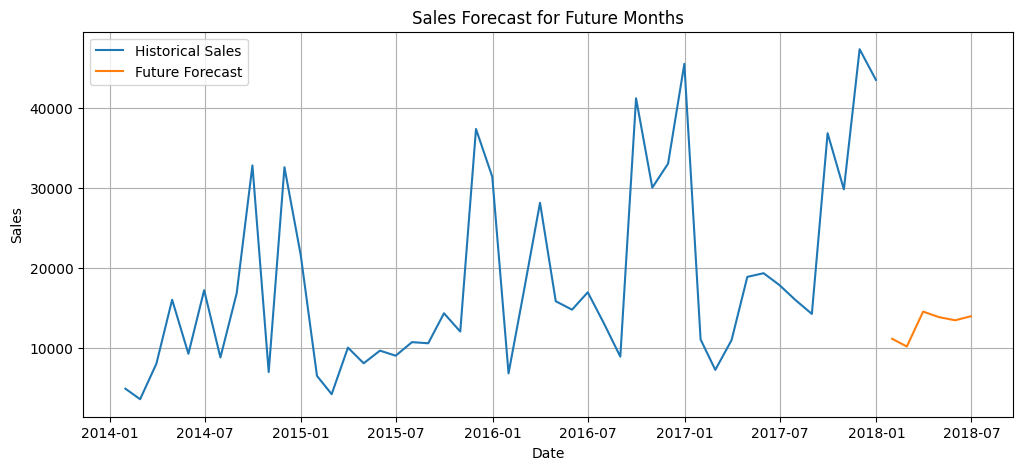

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(monthly_df["Order Date"], monthly_df["Sales"], label="Historical Sales")
plt.plot(future_df["Order Date"], future_df["Predicted Sales"], label="Future Forecast")
plt.title("Sales Forecast for Future Months")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

3


In [ ]:
classification_features = [
    "Sales",
    "Quantity",
    "Discount",
    "Category",
    "Sub-Category",
    "Region"
]

X_class = df[classification_features]
y_class = df["is_profitable"]

X_class = pd.get_dummies(X_class, drop_first=True)

print(X_class.head())
print(y_class.head())

      Sales  Quantity  Discount  Category_Office Supplies  \
0  261.9600         2      0.00                     False   
1  731.9400         3      0.00                     False   
2   14.6200         2      0.00                      True   
3  957.5775         5      0.45                     False   
4   22.3680         2      0.20                      True   

   Category_Technology  Sub-Category_Appliances  Sub-Category_Art  \
0                False                    False             False   
1                False                    False             False   
2                False                    False             False   
3                False                    False             False   
4                False                    False             False   

   Sub-Category_Binders  Sub-Category_Bookcases  Sub-Category_Chairs  ...  \
0                 False                    True                False  ...   
1                 False                   False                 

In [ ]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

print(X_train_c.shape, X_test_c.shape)

(3233, 24) (809, 24)


In [ ]:
classification_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

classification_model.fit(X_train_c, y_train_c)
print("Classification model trained successfully.")

Classification model trained successfully.


In [ ]:
y_pred_c = classification_model.predict(X_test_c)

accuracy = accuracy_score(y_test_c, y_pred_c)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c))



Accuracy: 0.9369592088998764

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.70      0.81       158
           1       0.93      1.00      0.96       651

    accuracy                           0.94       809
   macro avg       0.95      0.85      0.89       809
weighted avg       0.94      0.94      0.93       809



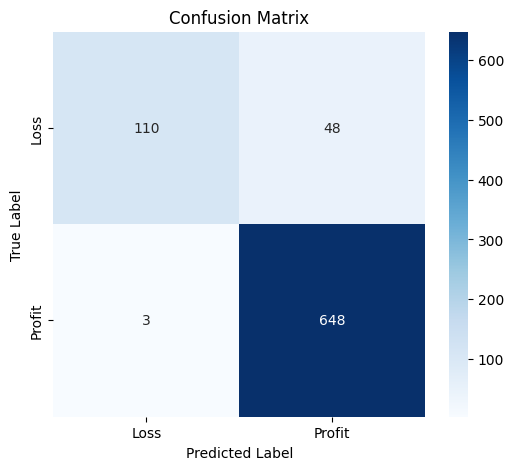

In [ ]:


# حساب الكنفيوجن ماتركس
cm = confusion_matrix(y_test_c, y_pred_c)

# الرسم
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Loss", "Profit"],
    yticklabels=["Loss", "Profit"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

Discount                0.688887
Sales                   0.094874
Sub-Category_Binders    0.029867
Quantity                0.029733
Sub-Category_Tables     0.021407
Region_West             0.019117
Sub-Category_Paper      0.017788
Sub-Category_Storage    0.014639
Sub-Category_Chairs     0.010913
Sub-Category_Art        0.008826
dtype: float64


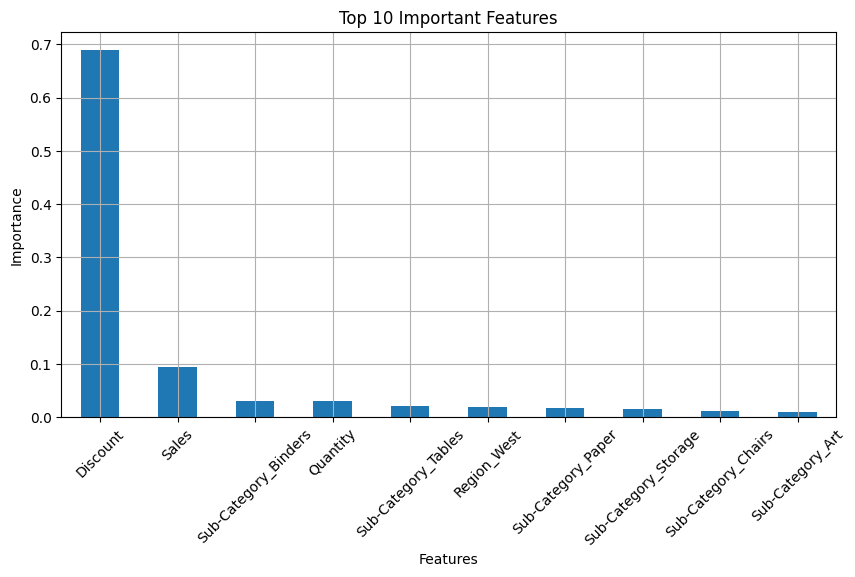

In [ ]:
importance = pd.Series(classification_model.feature_importances_, index=X_class.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

plt.figure(figsize=(10,5))
importance.head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
df_class_copy = df[classification_features].copy()
df_class_encoded = pd.get_dummies(df_class_copy, drop_first=True)

df_class_encoded = df_class_encoded.reindex(columns=X_class.columns, fill_value=0)

df["predicted_profitability"] = classification_model.predict(df_class_encoded)

risky_orders = df[df["predicted_profitability"] == 0]

print(risky_orders[["Order Date", "Sales", "Profit", "Discount", "Category", "Sub-Category", "Region"]].head(10))

   Order Date     Sales    Profit  Discount         Category Sub-Category  \
3  2015-10-11  957.5775 -383.0310      0.45        Furniture       Tables   
17 2016-12-08  190.9200 -147.9630      0.60        Furniture  Furnishings   
26 2017-12-09    1.2480   -1.9344      0.80  Office Supplies      Binders   
27 2017-12-09    9.7080   -5.8248      0.60        Furniture  Furnishings   
35 2017-11-06    5.6820   -3.7880      0.70  Office Supplies      Binders   
42 2015-04-05  157.7940 -115.7156      0.70  Office Supplies      Binders   
48 2017-11-05    2.3880   -1.8308      0.70  Office Supplies      Binders   
50 2016-11-06   81.4240   -9.1602      0.20        Furniture       Chairs   
52 2017-02-02   59.9700  -11.9940      0.40       Technology       Phones   
61 2014-03-01  457.5680   51.4764      0.20        Furniture       Chairs   

     Region  
3     South  
17  Central  
26  Central  
27  Central  
35     West  
42    South  
48     West  
50     West  
52     East  
61     West 

In [ ]:
forecast_results.to_csv("sales_forecast_results.csv", index=False)
future_df.to_csv("future_sales_predictions.csv", index=False)
risky_orders.to_csv("risky_orders.csv", index=False)

joblib.dump(forecast_model, "sales_forecast_model.pkl")
joblib.dump(classification_model, "profit_classification_model.pkl")

print("All files saved successfully.")

All files saved successfully.
